<a href="https://colab.research.google.com/github/KRBAI/Assignment-1/blob/main/Question2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 2

/tmp/ipython-input-3152669404.py:53: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(l_channel.ravel(), 256, [0, 256], color='gray', alpha=0.7)
/tmp/ipython-input-3152669404.py:60: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(l_corrected.ravel(), 256, [0, 256], color='gray', alpha=0.7)


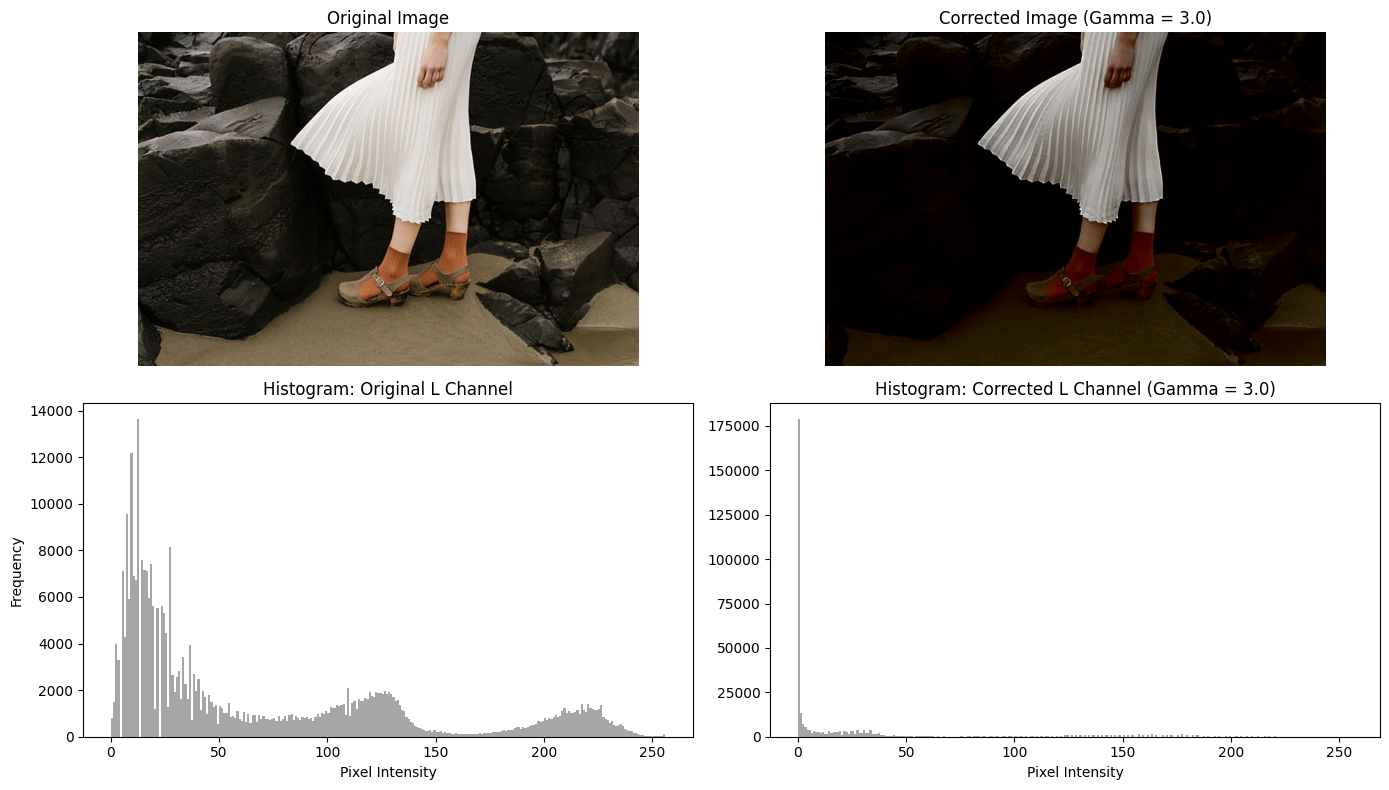

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image
# Replace 'fig2.jpg' with the actual filename of Figure 2
img_bgr = cv.imread('/content/drive/MyDrive/Assignment1/highlights_and_shadows.jpg')

# 2. Convert to Lab Color Space
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2Lab)

# 3. Split into L, a, and b channels
l_channel, a_channel, b_channel = cv.split(img_lab)

# 4. Define Gamma and Create Lookup Table (LUT)
gamma = 3.0
lut = np.array([((i / 255.0) ** gamma) * 255
                for i in np.arange(0, 256)]).astype(np.uint8).reshape(1, 256)

# 5. Apply Gamma Correction to the L channel ONLY
l_corrected = cv.LUT(l_channel, lut)

# 6. Merge back and convert to BGR
merged_lab = cv.merge((l_corrected, a_channel, b_channel))
img_corrected = cv.cvtColor(merged_lab, cv.COLOR_Lab2BGR)

# --- Visualization (Images & Histograms) ---
plt.figure(figsize=(14, 8))

# Original Image
plt.subplot(2, 2, 1)
# Convert BGR to RGB for Matplotlib display
plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

# Corrected Image
plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
plt.title(f"Corrected Image (Gamma = {gamma})")
plt.axis('off')

# Histogram: Original L Channel
plt.subplot(2, 2, 3)
plt.hist(l_channel.ravel(), 256, [0, 256], color='gray', alpha=0.7)
plt.title("Histogram: Original L Channel")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# Histogram: Corrected L Channel
plt.subplot(2, 2, 4)
plt.hist(l_corrected.ravel(), 256, [0, 256], color='gray', alpha=0.7)
plt.title(f"Histogram: Corrected L Channel (Gamma = {gamma})")
plt.xlabel("Pixel Intensity")

plt.tight_layout()
plt.show()